In [1]:
# Nombres y rutas configurables para guardar y cargar los modelos.
MODEL_NAME = "models/cat_dog_mobilenetv3DataAugmentationZoomOutV4"
MODEL_PATH = f"{MODEL_NAME}.keras"
WEIGHTS_PATH = f"{MODEL_NAME}.weights.h5"
TFLITE_PATH = f"{MODEL_NAME}.tflite"
OPTIMIZED_TFLITE_PATH = f"{MODEL_NAME}_optimized.tflite"
CHECKPOINT_DIR = "checkpoints"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/stage4.keras"


In [2]:
#clone from https://huggingface.co/Kavindutharaka/cat_dog_classifier/blob/main/cat_dog_classifier.ipynb

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import opendatasets as od
import cv2

I0000 00:00:1789578894.103050   60368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789578894.823012   60368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
#od.download("https://www.kaggle.com/datasets/dineshpiyasamara/cats-and-dogs-for-classification")

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = (224,224)

In [6]:
train_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/train"
test_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/test"

In [7]:
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='training',
                                                         validation_split=0.1,
                                                         seed=42)
validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='validation',
                                                         validation_split=0.1,
                                                         seed=42)
test_data = tf.keras.utils.image_dataset_from_directory(test_data_dir,
                                                        batch_size=BATCH_SIZE,
                                                        image_size=IMAGE_SIZE)

Found 8000 files belonging to 2 classes.
Using 7200 files for training.


W0000 00:00:1789578895.265336   60368 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789578895.267761   60368 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789578895.335749   60368 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


Found 8000 files belonging to 2 classes.
Using 800 files for validation.
Found 2000 files belonging to 2 classes.


In [8]:
class_names = train_data.class_names
class_names

['cats', 'dogs']

In [9]:
for image_batch, label_batch in train_data.take(1):
  print(image_batch.shape)
  print(label_batch.shape)

(32, 224, 224, 3)
(32,)


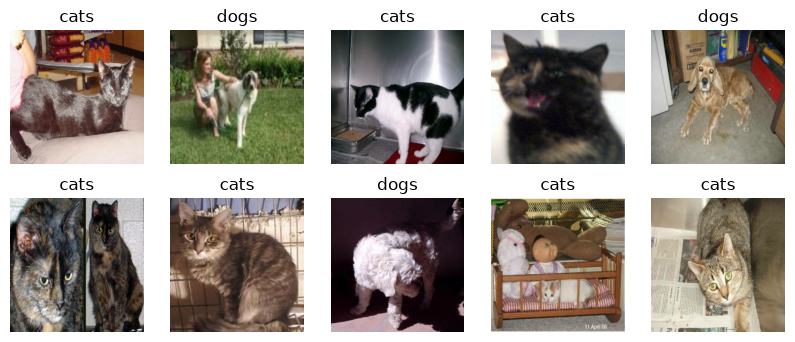

In [10]:
plt.figure(figsize=(10,4))
for image,label in train_data.take(1):
  for i in range(10):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')

In [11]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal",input_shape=(224,224,3)),
        #tf.keras.layers.RandomRotation(0.2),
        #tf.keras.layers.RandomZoom(0.2),
        #tf.keras.layers.RandomZoom(
        #    height_factor=(-0.2, 0.2),
        #    width_factor=(-0.2, 0.2)
        #),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.15, 0.50),
            fill_mode="constant",
            fill_value=255.0
        )
    ]
)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


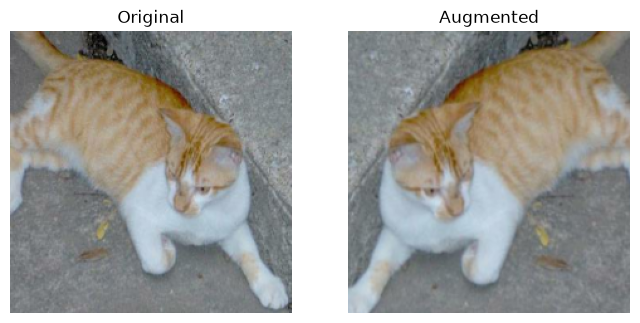

In [12]:
images, labels = next(iter(train_data))

image = images[0]

augmented_image = data_augmentation(
    tf.expand_dims(image, axis=0),
    training=True
)[0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(tf.cast(image, tf.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(augmented_image, tf.uint8))
plt.title("Augmented")
plt.axis("off")

plt.show()

In [13]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[3.93861618e+01 2.23861599e+01 3.23861618e+01]
   [3.80000000e+01 2.10000000e+01 3.10000000e+01]
   [4.00962257e+01 2.30962257e+01 3.30962257e+01]
   ...
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]]

  [[3.90000000e+01 2.20000000e+01 3.20000000e+01]
   [3.80000000e+01 2.10000000e+01 3.10000000e+01]
   [3.90118942e+01 2.20118923e+01 3.20118942e+01]
   ...
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]]

  [[3.79818993e+01 2.09818993e+01 3.09818993e+01]
   [3.90000000e+01 2.20000000e+01 3.20000000e+01]
   [3.78839302e+01 2.08839283e+01 3.08839283e+01]
   ...
   [0.00000000e+00 4.68750000e-02 0.00000000e+00]
   [0.00000000e+00 3.94463539e-02 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]]

  ...

  [[2.02826126e+02 1.78013626e+02 1.84154251e+02]
   [1

In [14]:
#transfer learning
pretrained_model = tf.keras.applications.xception.Xception(include_top=False,
                                                           input_shape=(224,224,3),
                                                           weights='imagenet',
                                                           pooling='max')
for layer in pretrained_model.layers:
  layer.trainable = False

In [15]:
MobileNetV3Small = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
#for layer in MobileNetV3Small.layers[:-20]:
#    layer.trainable = False
    
MobileNetV3Small.trainable = False
MobileNetV3Small.summary()

Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

In [16]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        #tf.keras.layers.RandomRotation(0.2),
        #tf.keras.layers.RandomZoom(0.2),
         tf.keras.layers.RandomZoom(
            height_factor=(0.35, 0.50),
            fill_mode="constant",
            fill_value=255.0
        )
    ]
)

In [17]:
callbacks = [
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        mode="min"
    )
]

In [18]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = MobileNetV3Small(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

#modelV2 = tf.keras.Sequential([
#    tf.keras.Input(shape=(224, 224, 3)),
    #data_augmentation,
#    MobileNetV3Small,
#    tf.keras.layers.GlobalAveragePooling2D(),
#    tf.keras.layers.Dropout(0.2),
#    tf.keras.layers.Dense(1, activation="sigmoid"),
#])

In [19]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [20]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

In [21]:
epochs = 100

In [22]:

start_time = time.time()

history_transfer  = model.fit(
    train_data,
    epochs=epochs,
    validation_data=validation_data,
    callbacks= callbacks
)
end_time = time.time()

Epoch 1/100


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1789578905.842881   60529 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9275 - loss: 0.2015 - val_accuracy: 0.9725 - val_loss: 0.0876
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9646 - loss: 0.0979 - val_accuracy: 0.9762 - val_loss: 0.0707
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9675 - loss: 0.0889 - val_accuracy: 0.9762 - val_loss: 0.0635
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9706 - loss: 0.0788 - val_accuracy: 0.9775 - val_loss: 0.0605
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9725 - loss: 0.0756 - val_accuracy: 0.9787 - val_loss: 0.0593
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9725 - loss: 0.0716 - val_accuracy: 0.9750 - val_loss: 0.0573
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9735 - loss: 0.0705 - val_accuracy: 0.9762 - val_loss: 0.0564
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9751 - loss: 0.0668 - val_accuracy: 0.97

In [23]:
history_transfer .history

{'accuracy': [0.9275000095367432,
  0.9645833373069763,
  0.9674999713897705,
  0.9705555438995361,
  0.9725000262260437,
  0.9725000262260437,
  0.9734722375869751,
  0.9751389026641846,
  0.9759722352027893,
  0.9740277528762817,
  0.9738888740539551,
  0.9756944179534912,
  0.9751389026641846,
  0.9777777791023254,
  0.9779166579246521,
  0.9779166579246521,
  0.9781944155693054,
  0.976111114025116,
  0.9770833253860474,
  0.9775000214576721,
  0.9762499928474426,
  0.9798611402511597,
  0.9777777791023254,
  0.9770833253860474,
  0.976805567741394,
  0.9780555367469788,
  0.9788888692855835,
  0.9795833230018616,
  0.9754166603088379,
  0.9794444441795349,
  0.9791666865348816,
  0.9788888692855835],
 'loss': [0.2015228420495987,
  0.09788864850997925,
  0.08893091231584549,
  0.07884291559457779,
  0.07559239864349365,
  0.07164574414491653,
  0.07046479731798172,
  0.06683702021837234,
  0.06490562111139297,
  0.06407995522022247,
  0.06475777924060822,
  0.06412864476442337,
  

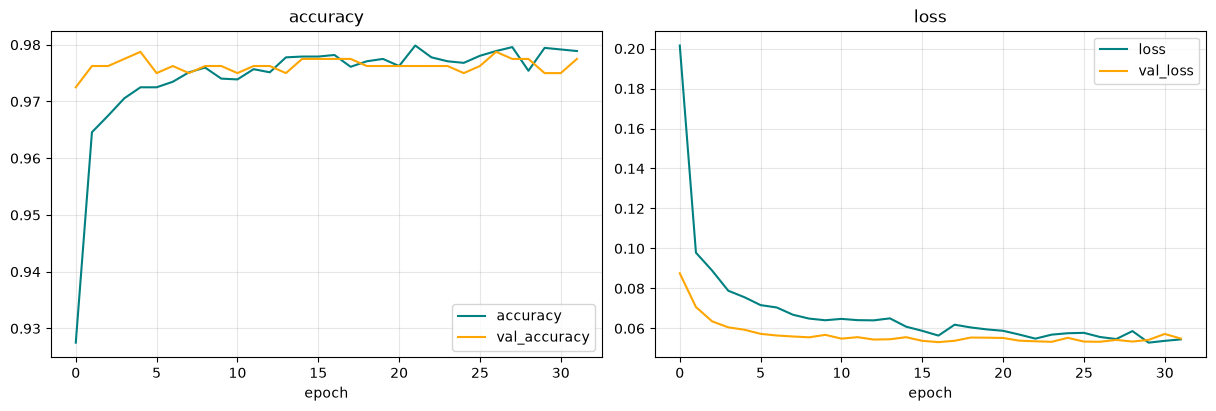

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_transfer .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_transfer .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_transfer .history["loss"], color="teal", label="loss")
axs[1].plot(history_transfer .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [25]:
timeV = end_time - start_time
timeV = timeV/60
timeV

1.2475700696309409

In [26]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

In [27]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━

E0000 00:00:1789578985.672057   60532 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [28]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9790419340133667
recall: 0.9810000061988831
accuracy: 0.9800000190734863


In [29]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
model.save(CHECKPOINT_PATH)

In [30]:
#fine tunning
MobileNetV3Small.trainable = True

for layer in MobileNetV3Small.layers[:-20]:
    layer.trainable = False

for layer in MobileNetV3Small.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min"
    )
]

model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 940,853 (3.59 MB)

 Trainable params: 347,473 (1.33 MB)

 Non-trainable params: 592,224 (2.26 MB)

 Optimizer params: 1,156 (4.52 KB)

In [31]:

start_time = time.time()

history_finetune  = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=fine_tune_callbacks
)
end_time = time.time()

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9781 - loss: 0.0579 - val_accuracy: 0.9775 - val_loss: 0.0518
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9785 - loss: 0.0536 - val_accuracy: 0.9775 - val_loss: 0.0510
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9812 - loss: 0.0515 - val_accuracy: 0.9787 - val_loss: 0.0501
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9800 - loss: 0.0480 - val_accuracy: 0.9775 - val_loss: 0.0495
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9819 - loss: 0.0477 - val_accuracy: 0.9775 - val_loss: 0.0492
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9831 - loss: 0.0450 - val_accuracy: 0.9775 - val_loss: 0.0487
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9843 - loss: 0.0437 - val_accuracy: 0.9762 - val_loss: 0.0485
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9851 - loss: 0.0412 - val_accuracy: 

In [32]:
history_finetune .history

{'accuracy': [0.9780555367469788,
  0.9784722328186035,
  0.981249988079071,
  0.9800000190734863,
  0.9819444417953491,
  0.9830555319786072,
  0.9843055605888367,
  0.9851388931274414,
  0.9844444394111633,
  0.9830555319786072,
  0.9852777719497681,
  0.9856944680213928,
  0.9884722232818604,
  0.9880555272102356,
  0.988611102104187,
  0.9879166483879089,
  0.9895833134651184,
  0.9900000095367432,
  0.9897222518920898,
  0.9916666746139526,
  0.9913889169692993],
 'loss': [0.057897910475730896,
  0.05364014208316803,
  0.05147109180688858,
  0.04795493185520172,
  0.047691259533166885,
  0.0450267493724823,
  0.04365125298500061,
  0.04116945341229439,
  0.04009280353784561,
  0.04052241891622543,
  0.03676304221153259,
  0.03669750690460205,
  0.03276420757174492,
  0.033143337815999985,
  0.03217350319027901,
  0.032282739877700806,
  0.030061140656471252,
  0.028228074312210083,
  0.028222844004631042,
  0.0246031042188406,
  0.026269514113664627],
 'val_accuracy': [0.977500021

In [33]:
timeV = end_time - start_time
timeV = timeV/60
timeV

0.8318333347638448

In [34]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

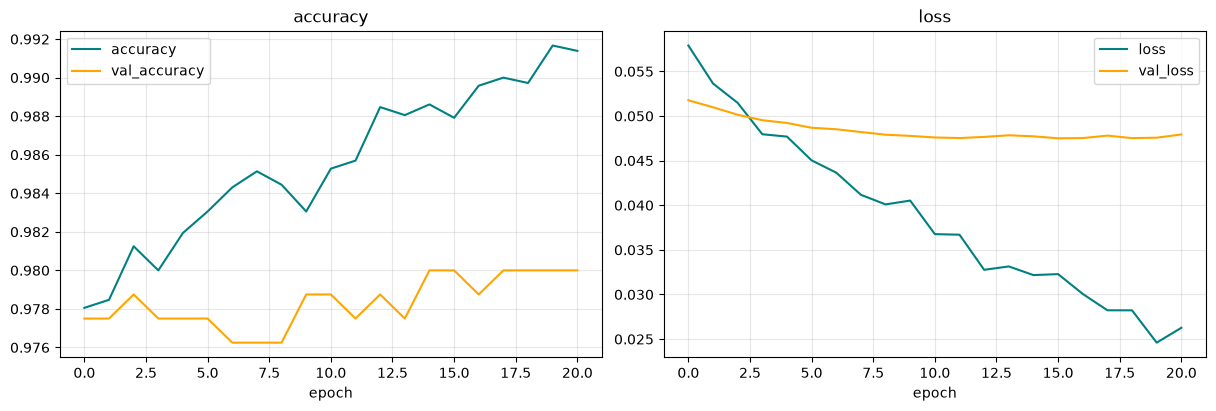

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_finetune .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_finetune .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_finetune .history["loss"], color="teal", label="loss")
axs[1].plot(history_finetune .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [36]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━

In [37]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9810379147529602
recall: 0.9829999804496765
accuracy: 0.9819999933242798


In [38]:
model.save(MODEL_PATH)

In [39]:
model.save_weights(
    WEIGHTS_PATH
)

In [40]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpqw9f2412/assets


INFO:tensorflow:Assets written to: /tmp/tmpqw9f2412/assets


Saved artifact at '/tmp/tmpqw9f2412'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  130096140160464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140160848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140167184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140166800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140166992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130111292026576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140167760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140166416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140159312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140168144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1300961401

W0000 00:00:1789579050.478981   60368 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789579050.479017   60368 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [41]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

tflite_optimized = converter.convert()

with open(
    OPTIMIZED_TFLITE_PATH,
    "wb"
) as f:
    f.write(tflite_optimized)

INFO:tensorflow:Assets written to: /tmp/tmpj2rrrebs/assets


INFO:tensorflow:Assets written to: /tmp/tmpj2rrrebs/assets


Saved artifact at '/tmp/tmpj2rrrebs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  130096140160464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140160848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140167184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140166800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140166992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130111292026576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140167760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140166416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140159312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130096140168144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1300961401

W0000 00:00:1789579054.634339   60368 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789579054.634373   60368 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [42]:
import os

print(
    "Normal:",
    os.path.getsize(TFLITE_PATH) / 1024 / 1024,
    "MB"
)

print(
    "Optimizado:",
    os.path.getsize(OPTIMIZED_TFLITE_PATH) / 1024 / 1024,
    "MB"
)

Normal: 3.5802764892578125 MB
Optimizado: 1.078948974609375 MB


E0000 00:00:1789579058.784391   60528 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


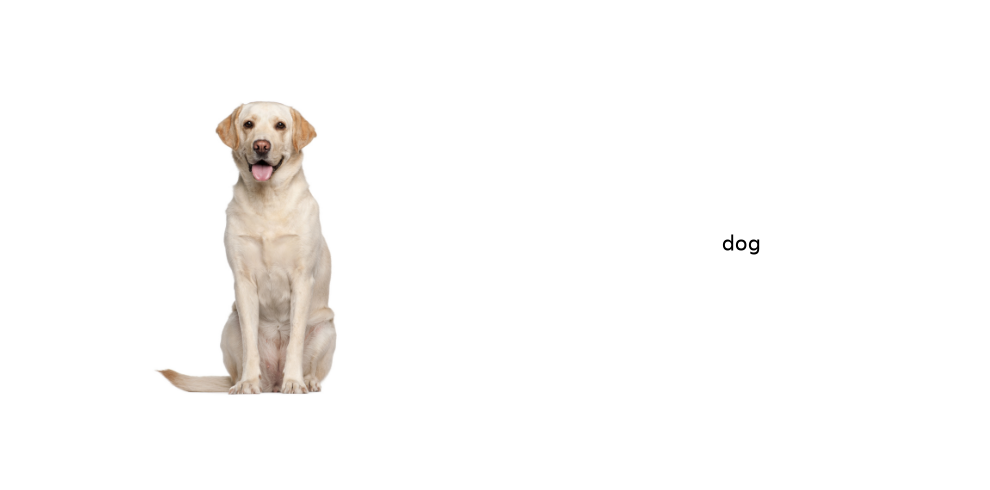

[[0.9998294]]


In [43]:
import keras
model = keras.saving.load_model(MODEL_PATH)

image = cv2.imread("dog.png")
if image is None:
    raise FileNotFoundError("Could not read dog.png from the current working directory.")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img = np.expand_dims(tf.image.resize(image, IMAGE_SIZE), 0)

y_hat = model.predict(img)

label = "dog" if y_hat > 0.5 else "cat"

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image)
axs[0].axis('off')
axs[1].text(0.5, 0.5, label, fontsize=15, ha='center', va='center')
axs[1].axis('off')
plt.tight_layout()
plt.show()

print(y_hat)